In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

In [2]:
adata = sc.read_h5ad("/Users/annatrize/Downloads/combined_heart_failure_adata.h5ad")
print(adata.shape)

(70443, 31053)


In [3]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
print(adata.shape)

(69458, 21763)


In [4]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=None)
adata = adata[adata.obs["pct_counts_mt"] < 10].copy()
print("Μετά το μιτοχονδριακό φιλτράρισμα:", adata.shape)

Μετά το μιτοχονδριακό φιλτράρισμα: (59783, 21763)


In [5]:
sc.pp.scrublet(adata, batch_key="sample")
adata = adata[~adata.obs["predicted_doublet"]].copy()
print("Μετά τα doublets:", adata.shape)

Μετά τα doublets: (59377, 21763)


In [6]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.raw = adata

In [7]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
adata_hvg = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata_hvg, max_value=10)

/Users/annatrize/miniconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [8]:
sc.tl.pca(adata_hvg, svd_solver="arpack")
sc.pp.neighbors(adata_hvg, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_hvg)
sc.tl.leiden(adata_hvg, resolution=0.02, flavor="igraph", n_iterations=2)
print(adata_hvg.obs["leiden"].value_counts())

/Users/annatrize/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


leiden
2    46834
1     7294
0     4250
3      980
4       19
Name: count, dtype: int64


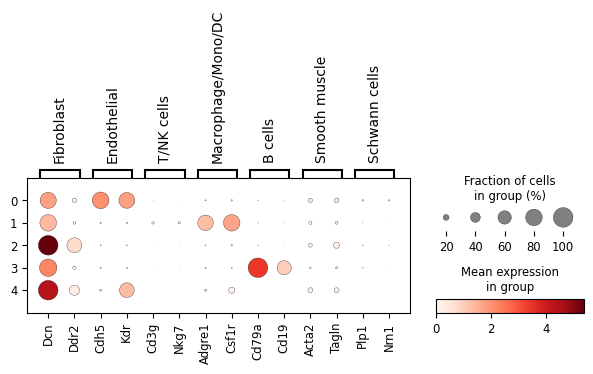

In [9]:
adata.obs["leiden"] = adata_hvg.obs["leiden"]

marker_genes = {
    "Fibroblast":          ["Dcn", "Ddr2"],
    "Endothelial":         ["Cdh5", "Kdr"],
    "T/NK cells":          ["Cd3g", "Nkg7"],
    "Macrophage/Mono/DC":  ["Adgre1", "Csf1r"],
    "B cells":             ["Cd79a", "Cd19"],
    "Smooth muscle":       ["Acta2", "Tagln"],
    "Schwann cells":       ["Plp1", "Nrn1"],
}
sc.pl.dotplot(adata, marker_genes, groupby="leiden")

In [10]:
cell_type_map = {"0":"Endothelial","1":"Macrophage/Mono/DC","2":"Fibroblast","3":"B cells","4":"T/NK cells"}
adata.obs["cell_type"] = adata.obs["leiden"].map(cell_type_map)
print(adata.obs["cell_type"].value_counts())

cell_type
Fibroblast            46834
Macrophage/Mono/DC     7294
Endothelial            4250
B cells                 980
T/NK cells               19
Name: count, dtype: int64


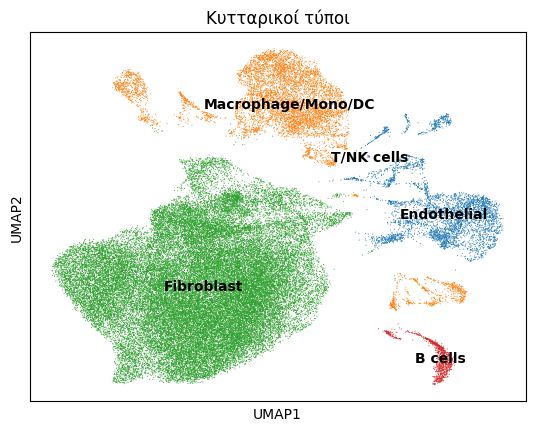

In [11]:
adata_hvg.obs["cell_type"] = adata.obs["cell_type"].values
sc.pl.umap(adata_hvg, color="cell_type", legend_loc="on data", title="Κυτταρικοί τύποι")

In [12]:
fibroblasts = adata[adata.obs["cell_type"] == "Fibroblast"].copy()
print("Ινοβλάστες:", fibroblasts.shape)

fibro_t4 = fibroblasts[fibroblasts.obs["timeline"] == "T4"].copy()
print("Ινοβλάστες T4:", fibro_t4.shape)
print(fibro_t4.obs["phenotype"].value_counts())

Ινοβλάστες: (46834, 21763)
Ινοβλάστες T4: (13142, 21763)
phenotype
CD34     6716
Total    6426
Name: count, dtype: int64


In [13]:
fibro_t4_nomt = fibro_t4[:, ~fibro_t4.var_names.str.startswith("mt-")].copy()

sc.tl.rank_genes_groups(fibro_t4_nomt, groupby="phenotype", groups=["CD34"], reference="Total", method="wilcoxon")
de_clean = sc.get.rank_genes_groups_df(fibro_t4_nomt, group="CD34")

sig = de_clean[de_clean["pvals_adj"] < 0.05]
top50_pos = sig.sort_values("logfoldchanges", ascending=False).head(50)
top50_neg = sig.sort_values("logfoldchanges", ascending=True).head(50)

print("=== TOP 50 ΘΕΤΙΚΑ (CD34) ===")
print("\n".join(top50_pos["names"].tolist()))
print("\n=== TOP 50 ΑΡΝΗΤΙΚΑ (Total) ===")
print("\n".join(top50_neg["names"].tolist()))

=== TOP 50 ΘΕΤΙΚΑ (CD34) ===
Atp6v0a4
Fabp4
Cthrc1
Gm17455
Ddah1
Postn
Clip4
mt-Nd4l
Scx
Acta2
Sema3d
Cytl1
Gm10076
Tmem255b
Rflnb
Crispld1
1500015O10Rik
Comp
Thbs4
Sema3c
Tagln
Limch1
Asap2
Hbegf
Crlf1
Ltbp2
Mgll
Ttc9
Anxa8
Esco1
Uchl1
Prg4
Tmem100
Pdgfa
Fgf18
Adgrg2
Mustn1
Myh10
Lgalsl
Cdk6
Cilp
Palld
Vcan
Sh3kbp1
Tpm1
Col14a1
Cst6
Ly6c1
Plod2
Wee1

=== TOP 50 ΑΡΝΗΤΙΚΑ (Total) ===
Igkc
Hbb-bs
S100a9
Il1b
S100a8
AY036118
Lars2
Gm42418
Rps27rt
Cd74
Ifitm1
Tpm3-rs7
Hsd11b1
Cxcl5
Apoe
H2-Ab1
Snhg9
Nmb
Inmt
Batf
Gng10
Ggt5
Wdr89
Col6a6
Srgn
Slco2b1
Dpep1
Sept4
Gfra1
Tap1
Cd82
Rgs17
C4b
Ftl1-ps1
Iigp1
Adm
Cxcl14
Ch25h
Igfbp3
Spon1
Gadd45a
Usp50
Steap4
Irgm1
Rtp4
Cyp27a1
S1pr3
H2-Q4
Gm8797
Clec2d


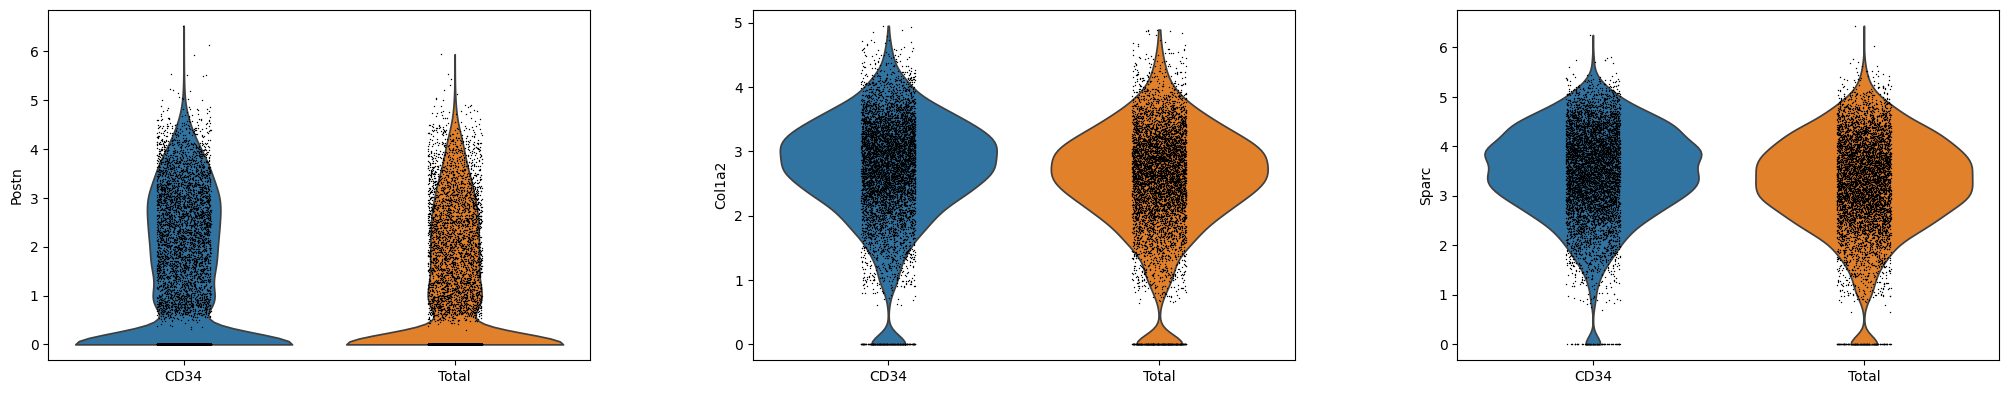

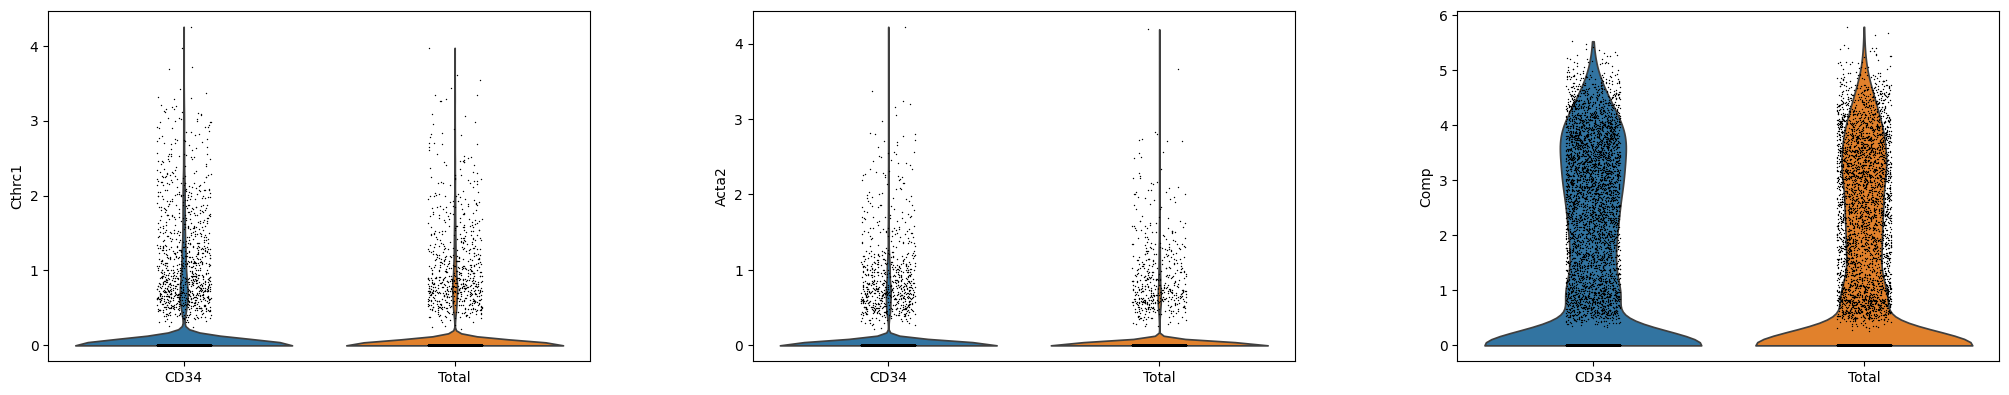

In [14]:
sc.pl.violin(fibro_t4, keys=["Postn", "Col1a2", "Sparc"], groupby="phenotype", rotation=0)
sc.pl.violin(fibro_t4, keys=["Cthrc1", "Acta2", "Comp"], groupby="phenotype", rotation=0)

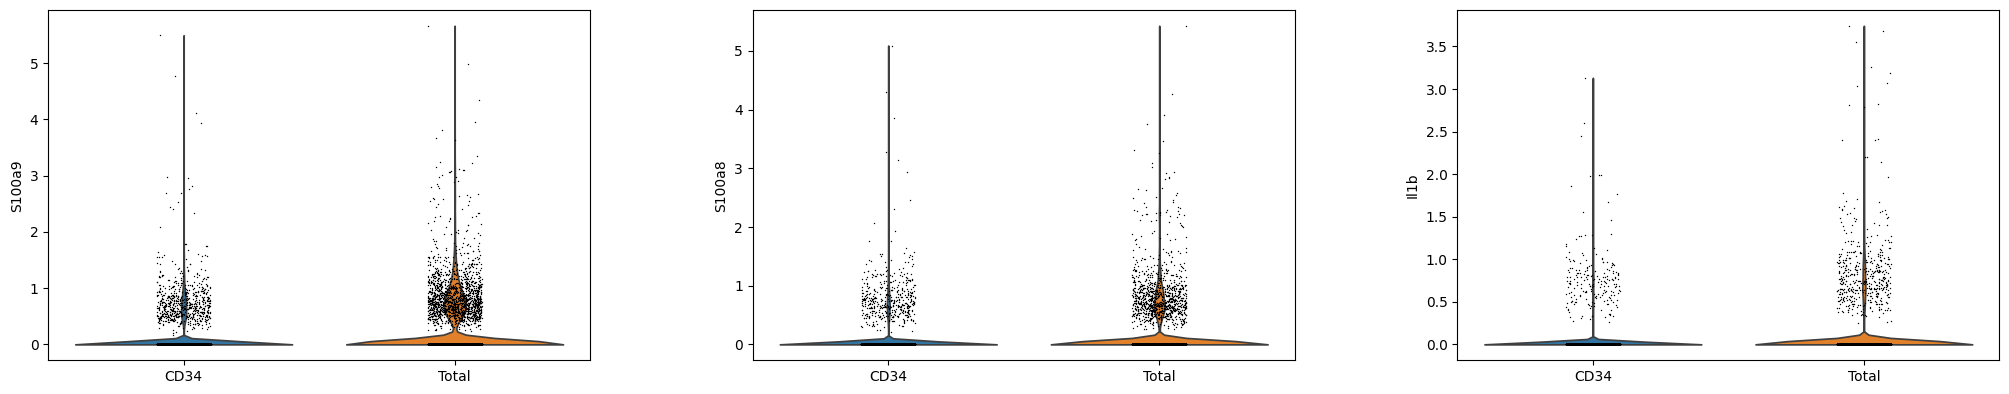

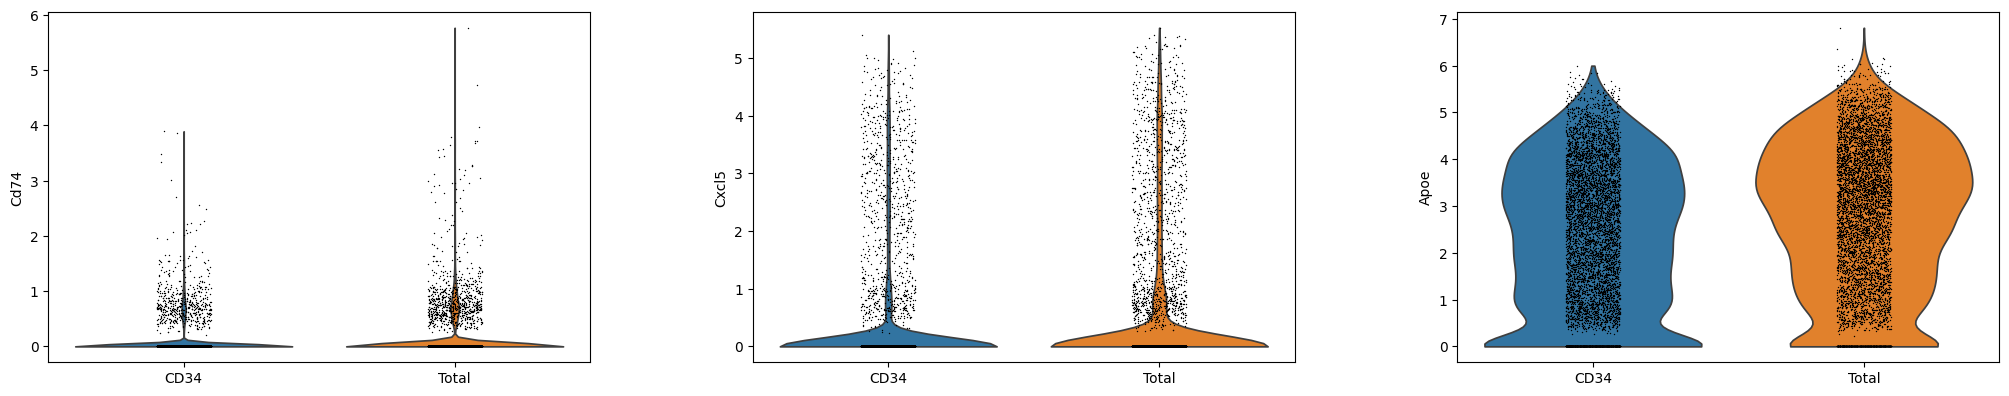

In [15]:
sc.pl.violin(fibro_t4, keys=["S100a9", "S100a8", "Il1b"], groupby="phenotype", rotation=0)
sc.pl.violin(fibro_t4, keys=["Cd74", "Cxcl5", "Apoe"], groupby="phenotype", rotation=0)